## LING 498 Hackathon - Prefix distributions (first 2–3 letters)

**Question: Are prefix strings Zipf-like, and which look most morphemic?**

- Data: Brown (or Gutenberg) tokens.
- Items to count: Lowercased prefixes: tok[:2] or tok[:3] (choose one, justify).

Steps:
- Filter to alphabetic tokens; lowercase.
- Extract 2- or 3-letter prefixes.
- Run Zipf report/plot.
- Interpret: true prefixes (re-, un-, dis-) vs coincidences (th-, co-).

Deliverable:
Top-15 prefixes + 2 limitations + one proposed “better proxy.”

In [ ]:
# import re
from nltk.corpus import brown
from nltk import FreqDist

# if NLTK gutenberg corpus isn't already downloaded in runtime, uncomment:
# nltk.download('brown')

In [8]:
# Helpter functions
def zipf_prep(items, min_count=1):
    fd = FreqDist(items)
    # drop ultra-rare if desired
    items2 = [(k,v) for k,v in fd.items() if v >= min_count]
    items2.sort(key=lambda kv: kv[1], reverse=True)
    return items2  # list of (item, count) sorted

def zipf_quick_report(items, title="", topn=15):
    ranked = zipf_prep(items)
    print(f"\n=== {title} ===")
    print(f"Types: {len(ranked)} | Tokens: {sum(c for _,c in ranked)}")
    print("Top items:")
    for i,(k,v) in enumerate(ranked[:topn], start=1):
        print(f"{i:>2}. {str(k)[:40]:<40} {v}")
    # simple “Zipf-ness” sanity check (no regression): f1 ~ 2*f2 ~ 3*f3?
    if len(ranked) >= 5:
        f1,f2,f3,f4,f5 = [ranked[i][1] for i in range(5)]
        print("\nHeuristic ratios (closer to 1 is more Zipf-like):")
        print(" f1/(2*f2) =", round(f1/(2*f2), 3))
        print(" f1/(3*f3) =", round(f1/(3*f3), 3))
        print(" f1/(4*f4) =", round(f1/(4*f4), 3))
        print(" f1/(5*f5) =", round(f1/(5*f5), 3))
    return ranked

# Optional plotting cell (instructor can pre-enable if matplotlib is available)
def zipf_plot(ranked, n=1000, title="Top 1000 _______"):
    import matplotlib.pyplot as plt
    ranks = list(range(1, min(n, len(ranked))+1))
    freqs = [ranked[i-1][1] for i in ranks]
    plt.figure(figsize=(6,4))
    plt.loglog(ranks, freqs, marker='.')
    plt.xlabel("rank (log)")
    plt.ylabel("frequency (log)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [9]:
# Load brown tokens
tokens = brown.words()
print(f"Loaded {len(tokens)} tokens from brown")

Loaded 1161192 tokens from brown


In [12]:
# Lowercased prefixes with words (first 2 or 3 letters)
prefixes = [
    token.lower()[:3] 
    for token in tokens
    # if not re.fullmatch(r"\W+", token) and len(token) >= 4 
]


=== Brown Prefix distributions ===
Types: 4549 | Tokens: 1161192
Top items:
 1. the                                      85291
 2. ,                                        58334
 3. .                                        49346
 4. of                                       36412
 5. and                                      29003
 6. to                                       26158
 7. a                                        23195
 8. in                                       21337
 9. tha                                      12730
10. for                                      12329
11. was                                      10405
12. is                                       10109
13. he                                       9548
14. ``                                       8837
15. ''                                       8789

Heuristic ratios (closer to 1 is more Zipf-like):
 f1/(2*f2) = 0.731
 f1/(3*f3) = 0.576
 f1/(4*f4) = 0.586
 f1/(5*f5) = 0.588


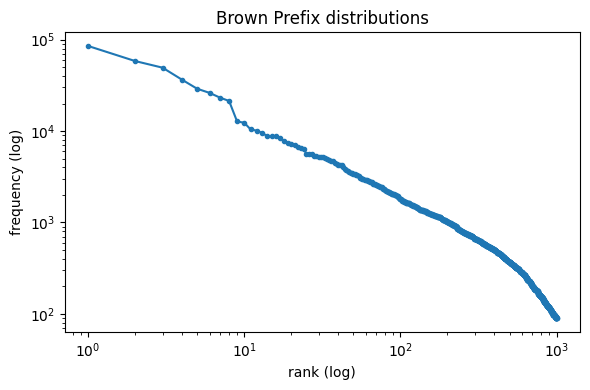

In [13]:
ranked = zipf_quick_report(prefixes, title="Brown Prefix distributions")
zipf_plot(ranked, title="Brown Prefix distributions")